In [4]:
import pandas as pd
vdb = pd.read_csv('vandenBerg_table2.csv') #import data from csv file, label it as vdb for convenience
print(vdb) #prints vdb so that the column titles are visible

    #NGC   Name   FeH    Age  Age_err Method   Figs        Range  HBtype  \
0    104  47Tuc -0.76  11.75     0.25      V     14  11.50–11.75   -0.99   
1    288   XXXX -1.32  11.50     0.38      H     24          NaN    0.98   
2    362   XXXX -1.30  10.75     0.25      V     13  10.75–11.00   -0.87   
3   1261   XXXX -1.27  10.75     0.25      V     13  10.75–11.25   -0.71   
4   1851   XXXX -1.18  11.00     0.25      V     13  10.75–11.25   -0.32   
5   2808   XXXX -1.18  11.00     0.38      V     13  11.00–11.25   -0.49   
6   3201   XXXX -1.51  11.50     0.38      A  12-30  11.25–11.75    0.08   
7   4147   XXXX -1.78  12.25     0.25      V     11  12.25–12.50    0.66   
8   4590    M68 -2.27  12.00     0.25      V     11        12.00    0.17   
9   4833   XXXX -1.89  12.50     0.50      A     30          NaN    0.93   
10  5024    M53 -2.06  12.25     0.25      V     12  12.25–12.50    0.81   
11  5053   XXXX -2.30  12.25     0.38      A     12  12.25–12.50    0.52   
12  5272    

**Notes on meaning of columns in the Table**
- **NGC** refers to New General Catalogue of nebulae and stellar clusters source: [Wikipedia](https://en.wikipedia.org/wiki/New_General_Catalogue)
- **FeH** is metallicity - log of ratio of iron and hydrogen comparative to the sun - check how this works
- The **Method** column refers to the method used to determine age - Vertical (V), Horizontal (H), Average of the two (A). I think that this is to do with how the isochrone that was fitted to the observed Colour Magnitude Diagram (CMD) was shifted (horizontally to match colour for example). Specifically, the vertical method compares the main sequence turn-off and the horizontal branch (HB), whereas the horizontal method compares the turnoff and the red giant branch
- The **Range** column refers to the range of ages determined by independent participants who determined the age based on their method
- **$v_e,0$** is the central escape velocity of the globular cluster, determined based on their estimations of the GC mass
- The GC mass was determined by assuming a Mass-to-Light ratio of $1.6(M/L_v)_\odot$, but this is not given in the table
- **R_G** is the galactocentric distance in kpc
- **M_V** is the absolute integrated magnitude in the visual band
- **HB Type** is to do with the distribution of stars around the 'instability strip' on the HB, given by $\frac{B-R}{B+V+R}$, where B is the number of stars on the HB to the left (blue) of the instability strip, V is the number of 'variable' stars within the instability strip (dominated by pulsating stars), and R is the number of stars to the right (red) of the instability strip.
-  **$log(\sigma_0)$** is the "common logarithm of the surface density of stars at the cluster center"


**notes on Van den Berg paper**
- " "low metallicities are not the exclusive result of an
earlier birth time compared to metal-rich disk and bulge GCs, but rather the result of a
lower mass host, considering the (observed) mass-metallicity relation in galaxies." In other
words, metal-poor globular clusters could simply be those systems that happened to form in
dwarf galaxies of low metallicity at whatever time the birth event occurred" (page 3)
- 

In [5]:
metallicity = vdb['FeH'] #extracts the column titled FeH and labels it metallicity
age = vdb['Age'] # age of the globular cluster in Gyr 
hbt = vdb['HBtype'] # Horizontal branch type (defined in Markdown cell above)
R_galaxy = vdb['R_G'] # galactocentric radius in kpc
magnitude = vdb['M_V'] # absolute integrated magnitude in the visual band
vel_esc = vdb['v_e0'] # escape velocity from the centre of the globular cluster in kms^-1 (proportional to sqrt(mass) I think)
stellar_density = vdb['log_sigma_0'] #log of the surfac density of stars at the cluster center




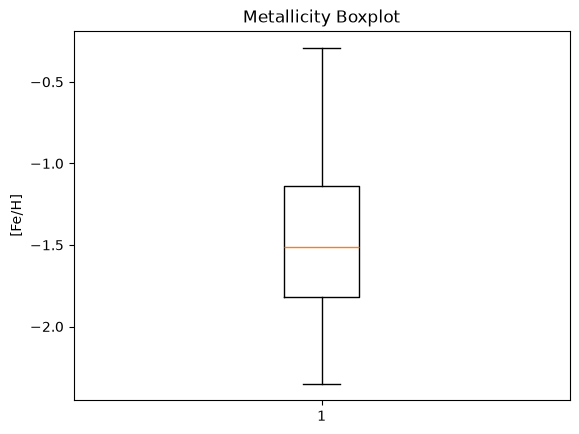

In [27]:
import matplotlib.pyplot as plt
feh = pd.DataFrame(metallicity) #This makes the column of metallicity easier to put into a box plot - turns it into its own data instead of being a subset of vdb
plt.boxplot(feh)
plt.title('Metallicity Boxplot')
plt.ylabel('[Fe/H]')
plt.show()



In [25]:
#This entire cell is me checking the metallicity column for outliers manually
#in order to check that the reason there's no outliers on my boxplot
#isn't just because I did something wrong while making it
from scipy import stats
import numpy as np
print('mean metallicity =', np.mean(feh))
from numpy import quantile
Q1_feh = quantile(metallicity, [0.25]) # define 1st quartile of metallicity
Q3_feh = quantile(metallicity,[0.75]) # define 3rd quartile of metallicity
iqr_feh = stats.iqr(metallicity) # finds IQR (could also be done by Q3-Q1)
print('Q1=',Q1_feh)
print('Q3=',Q3_feh)
print('IQR =', iqr_feh)
print('outlier cutoff =', Q1_feh-1.5*iqr_feh, Q3_feh+1.5*iqr_feh) #finds the cutoff below and above which values are considered outliers
print('max=', max(metallicity)) #Finds maximum value in the metallicity column
print('min=', min(metallicity)) #Finds the minimum value in the metallicity column


mean metallicity = -1.455818181818182
Q1= [-1.82]
Q3= [-1.14]
IQR = 0.6799999999999999
outlier cutoff = [-2.84] [-0.12]
max= -0.29
min= -2.35


There are no outliers in metallicity - no obvious candidates for accreted globular clusters based solely on low metallicity. What will be more helpful from here is looking at other variables related to accreted globular clusters and comparing those with the GCs with lower metallicity. I will also now make a histogram to check if the metallicity is bimodal.

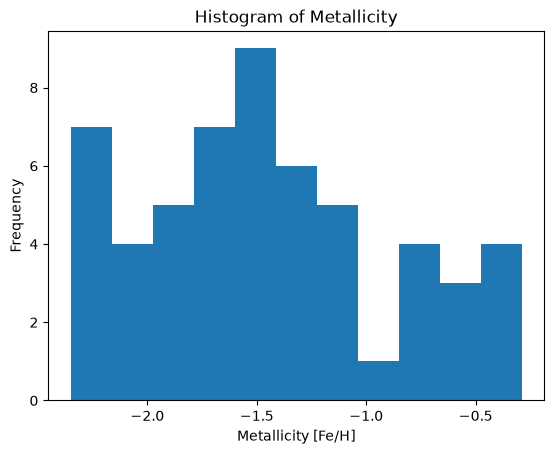

In [53]:
import matplotlib.pyplot as plt
plt.hist(feh, bins=11) #plots a histogram of the dataframe made from the metallicity column. Bin number controls how many divisions it is separated into. 
#Since the differences in metallicity are quite small, I decided it was appropriate to split it into more bins to capture the details of the data.  
# Splitting it into too many bins would have made the histogram not smooth enough to draw meaningful conclusions from, however. 
plt.title('Histogram of Metallicity')
plt.ylabel('Frequency')
plt.xlabel('Metallicity [Fe/H]')
plt.show()

We see that metallicity is weakly bimodal, with a spike at the lowest metallicities around -2.3 and another between ~-1.8 and -1.2. This is an indicator of accreted globular clusters (make sure to explain why this is in the video)